In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_clients = 250

data = {
    "client_id": [f"CL-{1000+i}" for i in range(num_clients)],
    "transaction_volume": np.random.randint(10000, 1000000, num_clients),
    "country_risk_score": np.random.randint(1, 11, num_clients),
    "recent_profile_change": np.random.choice([0, 1], num_clients, p=[0.75, 0.25]),
    "legal_or_regulatory_flag": np.random.choice([0, 1], num_clients, p=[0.85, 0.15]),
    "unusual_activity_score": np.random.randint(1, 11, num_clients),
    "days_since_last_review": np.random.randint(1, 365, num_clients)
}

df = pd.DataFrame(data)

df["risk_score"] = (
    df["country_risk_score"] * 1.5 +
    df["recent_profile_change"] * 3 +
    df["legal_or_regulatory_flag"] * 4 +
    df["unusual_activity_score"] * 2 +
    (df["days_since_last_review"] / 100)
)

df["risk_label"] = np.where(df["risk_score"] >= 18, 1, 0)

df.head()

,client_id,transaction_volume,country_risk_score,recent_profile_change,legal_or_regulatory_flag,unusual_activity_score,days_since_last_review,risk_score,risk_label
0,CL-1000,131958,1,0,0,1,282,6.32,0
1,CL-1001,681155,3,0,0,3,86,11.36,0
2,CL-1002,141932,10,0,0,6,250,29.50,1
3,CL-1003,375838,8,0,0,8,270,30.70,1
4,CL-1004,269178,6,0,0,9,335,30.35,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features (what the model uses)
X = df.drop(columns=["client_id", "risk_label", "risk_score"])

# Target (what we're predicting)
y = df["risk_label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[18  1]
 [ 4 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        19
           1       0.96      0.87      0.92        31

    accuracy                           0.90        50
   macro avg       0.89      0.91      0.90        50
weighted avg       0.91      0.90      0.90        50



In [5]:
# Sort by highest calculated risk score
high_risk_clients = df[df['risk_label'] == 1]
high_risk_clients_sorted = high_risk_clients.sort_values(by="risk_score", ascending=False)

high_risk_clients_sorted.head(10)

,client_id,transaction_volume,country_risk_score,recent_profile_change,legal_or_regulatory_flag,unusual_activity_score,days_since_last_review,risk_score,risk_label
52,CL-1052,601723,10,0,0,10,236,37.36,1
247,CL-1247,760216,5,1,1,10,210,36.60,1
177,CL-1177,934414,7,0,1,10,168,36.18,1
227,CL-1227,298249,10,0,0,10,74,35.74,1
246,CL-1246,670890,7,0,1,10,120,35.70,1
115,CL-1115,477281,8,1,0,10,61,35.61,1
167,CL-1167,904498,10,0,0,10,40,35.40,1
169,CL-1169,501234,10,0,0,10,40,35.40,1
229,CL-1229,418923,10,0,1,7,224,35.24,1
31,CL-1031,194779,10,0,0,8,349,34.49,1


In [6]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
4,unusual_activity_score,0.502535
1,country_risk_score,0.245414
5,days_since_last_review,0.110031
0,transaction_volume,0.104870
2,recent_profile_change,0.019572
3,legal_or_regulatory_flag,0.017578


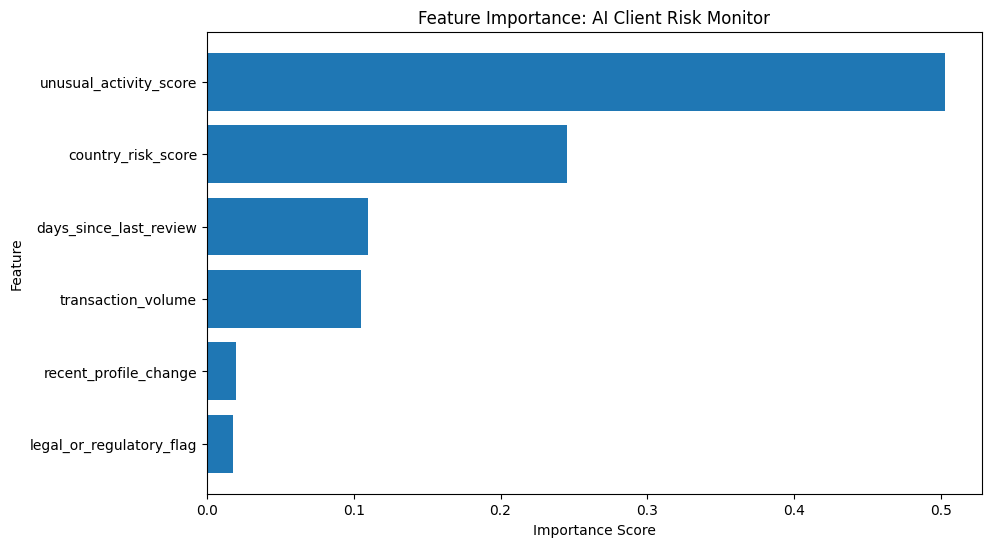

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance: AI Client Risk Monitor")
plt.gca().invert_yaxis()
plt.show()

In [9]:
df["predicted_risk"] = model.predict(X)

high_risk_clients = df[df["predicted_risk"] == 1].sort_values(
    by="risk_score",
    ascending=False
)

high_risk_clients.to_csv("flagged_high_risk_clients.csv", index=False)

print("Export complete: flagged_high_risk_clients.csv")

Export complete: flagged_high_risk_clients.csv
